In [1]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularPredictor
from sklearn.metrics import recall_score, confusion_matrix, accuracy_score, precision_score, f1_score

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
import json

from autogluon.tabular import TabularPredictor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, average_precision_score
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
PALETTE = ['#2196F3', '#F44336']

os.makedirs('models', exist_ok=True)
print('All libraries loaded successfully.')


In [2]:
# 1. Load datasets
train_data = pd.read_csv('Training.csv')
test_data = pd.read_csv('Testing.csv')

In [3]:
train_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
train_data.shape

(2460, 9)

In [5]:
test_data.shape

(308, 9)

In [6]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2460 entries, 0 to 2459
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2460 non-null   int64  
 1   Glucose                   2460 non-null   int64  
 2   BloodPressure             2460 non-null   int64  
 3   SkinThickness             2460 non-null   int64  
 4   Insulin                   2460 non-null   int64  
 5   BMI                       2460 non-null   float64
 6   DiabetesPedigreeFunction  2460 non-null   float64
 7   Age                       2460 non-null   int64  
 8   Outcome                   2460 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 173.1 KB


In [7]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               308 non-null    int64  
 1   Glucose                   308 non-null    int64  
 2   BloodPressure             308 non-null    int64  
 3   SkinThickness             308 non-null    int64  
 4   Insulin                   308 non-null    int64  
 5   BMI                       308 non-null    float64
 6   DiabetesPedigreeFunction  308 non-null    float64
 7   Age                       308 non-null    int64  
 8   Outcome                   308 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 21.8 KB


In [8]:
train_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000
mean,3.817480,121.602033,68.915041,20.531301,80.119919,31.990447,0.491440,32.821951,0.390244
std,3.296458,31.789270,19.082655,15.716901,116.765807,7.802569,0.363917,11.251208,0.487904
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,100.000000,64.000000,0.000000,0.000000,27.100000,0.251750,24.000000,0.000000
50%,3.000000,117.000000,70.000000,23.000000,36.000000,32.100000,0.381000,29.000000,0.000000
75%,6.000000,142.000000,80.000000,33.000000,129.000000,36.500000,0.647000,39.000000,1.000000
max,17.000000,197.000000,122.000000,63.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
test_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000
mean,3.863636,119.983766,69.503247,20.694805,77.724026,31.865909,0.445042,33.730519,0.301948
std,3.381437,31.186260,19.555067,16.298250,106.528025,7.427594,0.297660,12.208374,0.459850
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.085000,21.000000,0.000000
25%,1.000000,97.750000,62.000000,0.000000,0.000000,27.400000,0.228250,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,17.000000,32.000000,0.348000,29.000000,0.000000
75%,6.000000,136.000000,80.000000,32.000000,127.750000,36.425000,0.600000,42.000000,1.000000
max,13.000000,199.000000,114.000000,99.000000,600.000000,57.300000,1.699000,70.000000,1.000000


In [10]:
train_data.duplicated().sum()

2000

In [11]:
test_data.duplicated().sum()

0

In [12]:
# 2. Preprocessing: Handling the zeros in both sets
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
train_data[cols_with_zeros] = train_data[cols_with_zeros].replace(0, np.nan)
test_data[cols_with_zeros] = test_data[cols_with_zeros].replace(0, np.nan)

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get Correlations
correlations = train_data.corr()['Outcome'].drop('Outcome').abs().sort_values(ascending=False)

In [14]:
# Train AutoGluon — optimising for Recall (clinical priority: catch every diabetic)
# path= is REQUIRED so the Streamlit app can load the predictor from a fixed location
predictor = TabularPredictor(
    label='Outcome',
    eval_metric='recall',
    path='AutogluonModels/ag_model'
).fit(
    train_data,
    presets='best_quality',
    time_limit=600
)
print('Training complete. Model saved to AutogluonModels/ag_model/')


No path specified. Models will be saved in: "AutogluonModels/ag-20260310_190949"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.12.7
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.3.0: Wed Jan 28 20:54:22 PST 2026; root:xnu-12377.81.4~5/RELEASE_ARM64_T6030
CPU Count:          12
Memory Avail:       3.26 GB / 18.00 GB (18.1%)
Disk Space Avail:   144.32 GB / 460.43 GB (31.3%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_

(_ray_fit pid=58390) [1000]	valid_set's binary_logloss: 0.299193	valid_set's recall: 0.773585


(_dystack pid=58196) 	0.9519	 = Validation score   (recall)
(_dystack pid=58196) 	2.76s	 = Training   runtime
(_dystack pid=58196) 	0.22s	 = Validation runtime
(_dystack pid=58196) Fitting model: NeuralNetTorch_r22_BAG_L1 ... Training model for up to 40.05s of the 89.40s of remaining time.
(_dystack pid=58196) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (8 workers, per: cpus=1, gpus=0, memory=0.02%)
(_ray_fit pid=58359) No improvement since epoch 22: early stopping [repeated 3x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(_dystack pid=58196) 	0.9965	 = Validation score   (recall)
(_dystack pid=58196) 	6.36s	 = Training   runtime
(_dystack pid=58196) 	0.05s	 = Validation runtime
(_dystack pid=58196) Fitting model: XGBoost_r33_BAG_L1 ... Training model for up to 32

Computing feature importance via permutation shuffling for 8 features using 308 rows with 5 shuffle sets...
/Users/apple/miniforge3/lib/python3.12/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")
/Users/apple/miniforge3/lib/python3.12/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  wa

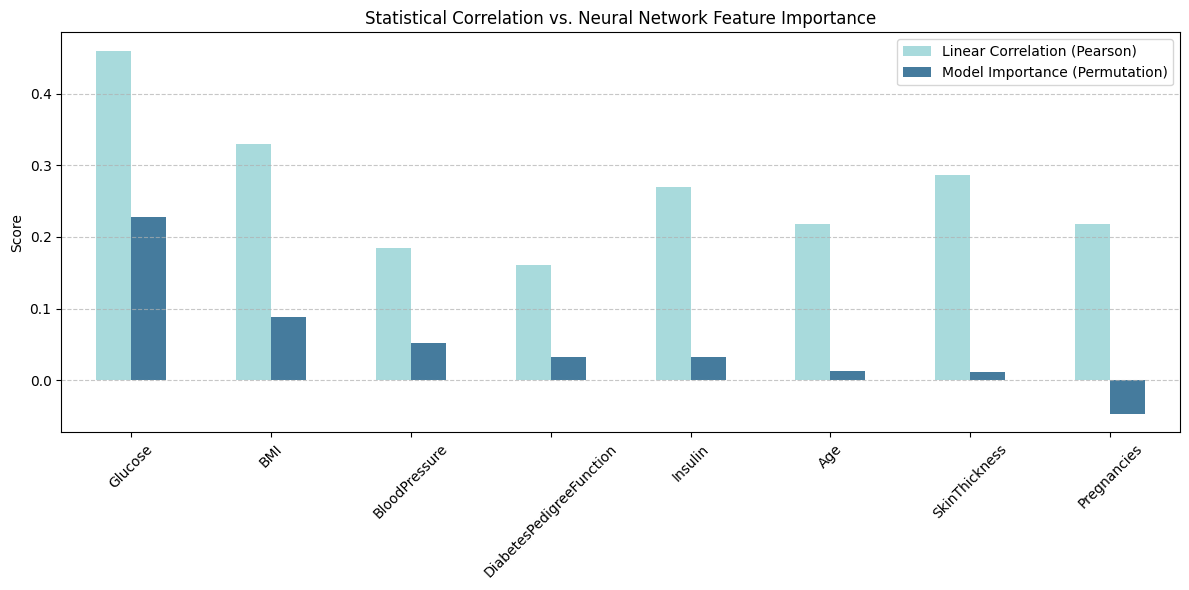

In [15]:
# 2. Get Model Feature Importance
# Ensure 'predictor' and 'test_data' are defined from your previous steps
importance = predictor.feature_importance(test_data, model='NeuralNetFastAI_r4_BAG_L1')
model_importance = importance['importance']

# 3. Combine into one DataFrame for plotting
df_compare = pd.DataFrame({
    'Linear Correlation': correlations,
    'Model Importance': model_importance
}).sort_values(by='Model Importance', ascending=False)

# 4. Plot Side-by-Side
fig, ax1 = plt.subplots(figsize=(12, 6))

df_compare.plot(kind='bar', ax=ax1, color=['#A8DADC', '#457B9D'])
plt.title('Statistical Correlation vs. Neural Network Feature Importance')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(["Linear Correlation (Pearson)", "Model Importance (Permutation)"])
plt.tight_layout()
plt.show()

In [16]:
#2. Comprehensive Leaderboard
# This shows all models ranked by Recall, but including other metrics
print("\n--- Multi-Metric Leaderboard ---")
metrics = ['accuracy', 'precision', 'f1', 'balanced_accuracy']
lb = predictor.leaderboard(test_data, extra_metrics=metrics)
print(lb)


--- Multi-Metric Leaderboard ---


/Users/apple/miniforge3/lib/python3.12/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")
/Users/apple/miniforge3/lib/python3.12/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when load

                           model  score_test  accuracy  precision        f1  \
0    NeuralNetFastAI_r187_BAG_L1    1.000000  0.321429   0.307947  0.470886   
1    NeuralNetFastAI_r143_BAG_L1    1.000000  0.487013   0.370518  0.540698   
2    NeuralNetFastAI_r156_BAG_L1    0.881720  0.409091   0.324111  0.473988   
3     NeuralNetFastAI_r65_BAG_L1    0.860215  0.418831   0.325203  0.471976   
4      NeuralNetFastAI_r4_BAG_L1    0.817204  0.782468   0.603175  0.694064   
..                           ...         ...       ...        ...       ...   
106           XGBoost_r34_BAG_L1    0.580645  0.788961   0.675000  0.624277   
107     RandomForest_r195_BAG_L1    0.580645  0.762987   0.613636  0.596685   
108         LightGBM_r161_BAG_L1    0.569892  0.792208   0.688312  0.623529   
109         LightGBM_r121_BAG_L1    0.548387  0.788961   0.689189  0.610778   
110         LightGBMLarge_BAG_L1    0.526882  0.756494   0.612500  0.566474   

     balanced_accuracy  score_val eval_metric  pred

In [17]:
from sklearn.metrics import recall_score, accuracy_score, precision_score, f1_score, confusion_matrix
# 1. LOCK IN YOUR CHOSEN MODEL
# This is the 'NeuralNetFastAI_r4_BAG_L1' you found on the leaderboard
specific_model = 'NeuralNetFastAI_r4_BAG_L1'

In [18]:
# 2. GET PROBABILITIES FROM THIS SPECIFIC MODEL
# Note: We must specify 'model=specific_model' here
probs = predictor.predict_proba(test_data, model=specific_model).iloc[:, 1]

/Users/apple/miniforge3/lib/python3.12/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")
/Users/apple/miniforge3/lib/python3.12/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when load

In [19]:
# 3. APPLY YOUR CUSTOM THRESHOLD
# 0.30 is your sweet spot for balancing Recall and Accuracy
threshold = 0.50
custom_preds = (probs >= threshold).astype(int)

In [20]:
# 4. FINAL PERFORMANCE REPORT
y_true = test_data['Outcome']

print(f"--- Final Evaluation: {specific_model} ---")
print(f"Decision Threshold: {threshold}")
print("-" * 40)
print(f"Recall:    {recall_score(y_true, custom_preds):.4f} (Priority Metric)")
print(f"Accuracy:  {accuracy_score(y_true, custom_preds):.4f}")
print(f"Precision: {precision_score(y_true, custom_preds):.4f}")
print(f"F1 Score:  {f1_score(y_true, custom_preds):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, custom_preds))

--- Final Evaluation: NeuralNetFastAI_r4_BAG_L1 ---
Decision Threshold: 0.5
----------------------------------------
Recall:    0.8172 (Priority Metric)
Accuracy:  0.7825
Precision: 0.6032
F1 Score:  0.6941

Confusion Matrix:
[[165  50]
 [ 17  76]]


  0%|          | 0/10 [00:00<?, ?it/s]

/var/folders/nf/lf5c5qk55xj1z2xkcnjnds3c0000gn/T/ipykernel_58175/3705023077.py:24: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, test_sample)


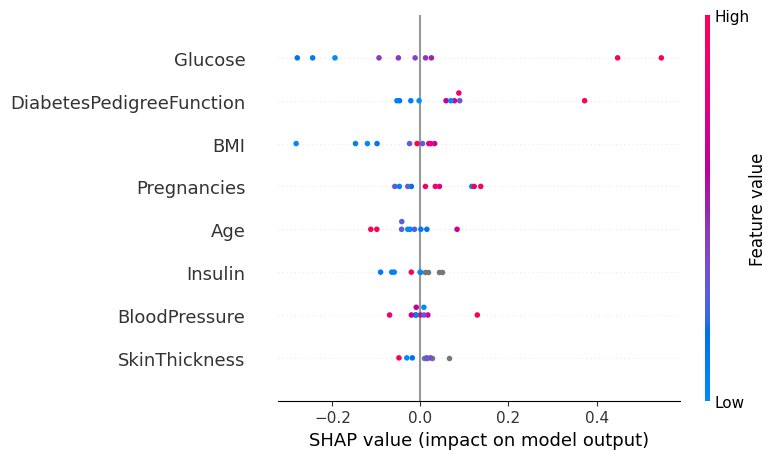

In [27]:
import shap


X_cols = train_data.drop(columns=['Outcome']).columns
def predict_proba_wrapper(numpy_array):
    df = pd.DataFrame(numpy_array, columns=X_cols)
    return predictor.predict_proba(df).iloc[:, 1].values

# 3. Use the features only (Drop 'Outcome') for the explainer
# We use .values to keep SHAP in its preferred format
background_data = train_data.drop(columns=['Outcome']).sample(50)
test_sample = test_data.drop(columns=['Outcome']).sample(10)

explainer = shap.KernelExplainer(predict_proba_wrapper, background_data)
shap_values = explainer.shap_values(test_sample)

shap.summary_plot(shap_values, test_sample)

## Save Artifacts for the Streamlit App
Save all artefacts the Streamlit app needs: predictor path, threshold, feature list,
leaderboard CSV, computed metrics, and SHAP explainer.

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# SAVE ARTIFACTS FOR STREAMLIT APP
# ══════════════════════════════════════════════════════════════════════════════

FEAT_COLS = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
             'Insulin','BMI','DiabetesPedigreeFunction','Age']

# -- Threshold (already defined in cell 19 as `threshold`) --------------------
joblib.dump(threshold, 'models/threshold.pkl')
joblib.dump(FEAT_COLS, 'models/feature_cols.pkl')

# -- Leaderboard CSV (all AutoGluon models) -----------------------------------
lb = predictor.leaderboard(
    test_data,
    extra_metrics=['accuracy','precision','f1','roc_auc'],
    silent=True
)
# Rename to the column names the app table expects
lb_clean = lb[['model','score_test','accuracy','precision','f1','roc_auc']].copy()
lb_clean.columns = ['Model','Recall','Accuracy','Precision','F1-Score','AUC-ROC']
lb_clean = lb_clean.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
lb_clean.to_csv('models/model_leaderboard.csv', index=False)
print('Leaderboard saved:')
print(lb_clean.to_string(index=False))

# -- Metrics for the chosen specific_model ------------------------------------
y_true   = test_data['Outcome']
probs_bm = predictor.predict_proba(test_data, model=specific_model).iloc[:, 1]
preds_bm = (probs_bm >= threshold).astype(int)

meta = {
    'best_model':      specific_model,
    'predictor_path':  'AutogluonModels/ag_model',
    'threshold':       float(threshold),
    'features':        FEAT_COLS,
    'eval_metric':     'recall',
    'presets':         'best_quality',
    'test_auc':        round(float(roc_auc_score(y_true, probs_bm)), 4),
    'test_f1':         round(float(f1_score(y_true, preds_bm)), 4),
    'test_recall':     round(float(recall_score(y_true, preds_bm)), 4),
    'test_accuracy':   round(float(accuracy_score(y_true, preds_bm)), 4),
    'test_precision':  round(float(precision_score(y_true, preds_bm)), 4),
}
with open('models/metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)
print('\nmetadata.json saved.')

# -- SHAP KernelExplainer (wraps AutoGluon predict_proba) ---------------------
try:
    import shap
    X_cols = train_data.drop(columns=['Outcome']).columns.tolist()

    def _ag_predict(numpy_array):
        df = pd.DataFrame(numpy_array, columns=X_cols)
        return predictor.predict_proba(df, model=specific_model).iloc[:, 1].values

    background      = shap.kmeans(train_data.drop(columns=['Outcome']).values.astype(float), 50)
    shap_explainer  = shap.KernelExplainer(_ag_predict, background)
    joblib.dump(shap_explainer, 'models/shap_explainer.pkl')
    print('SHAP explainer saved.')
except Exception as e:
    print(f'SHAP save skipped: {e}')

# -- Summary ------------------------------------------------------------------
print(f'\n{"="*55}')
print('  ARTIFACT SAVE SUMMARY')
print(f'{"="*55}')
for fname in sorted(os.listdir('models')):
    size = os.path.getsize(f'models/{fname}')
    print(f'  {fname:<38} {size:>10,} bytes')
print(f'\n  Best Model  : {specific_model}')
print(f'  Threshold   : {threshold}')
print(f'  AUC-ROC     : {meta["test_auc"]:.4f}')
print(f'  Recall      : {meta["test_recall"]:.4f}')
print(f'  F1-Score    : {meta["test_f1"]:.4f}')
print(f'{"="*55}')


NameError: name 'joblib' is not defined

In [29]:
from fairlearn.metrics import MetricFrame, selection_rate, demographic_parity_difference
from sklearn.metrics import accuracy_score

# Create a binary 'Senior' column for the audit
is_senior = X_test['Age'] > 50

# Analyze accuracy and selection rate across age groups
metrics = {
    'accuracy': accuracy_score,
    'selection_rate': selection_rate
}

mf = MetricFrame(metrics=metrics,
                 y_true=y_test,
                 y_pred=predictor.predict(X_test),
                 sensitive_features=is_senior)

print(mf.by_group)

       accuracy  selection_rate
Age                            
False  0.798535        0.289377
True   0.600000        0.371429


In [ ]:
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric

# 1. Define the sensitive attribute and groups
# Assuming Age >= 50 is 'privileged' and Age < 50 is 'unprivileged' in this context
sensitive_attr = 'Age'
privileged_groups = [{'Age': 1}] # 1 for older
unprivileged_groups = [{'Age': 0}] # 0 for younger

# 2. Binary mapping for AIF360 (The lab logic)
df_fair = train_data.copy()
df_fair['Age'] = (df_fair['Age'] >= 50).astype(int)

# 3. Create the BinaryLabelDataset
raw_dataset = BinaryLabelDataset(df=df_fair, label_name='Outcome', 
                                 favorable_label=0, unfavorable_label=1,
                                 protected_attribute_names=[sensitive_attr])

# 4. Calculate Initial Metrics
metric_orig = BinaryLabelDatasetMetric(raw_dataset, 
                                       unprivileged_groups=unprivileged_groups, 
                                       privileged_groups=privileged_groups)

print(f"Original Disparate Impact: {metric_orig.disparate_impact():.4f}")
print(f"Original Statistical Parity Difference: {metric_orig.statistical_parity_difference():.4f}")

In [ ]:
from aif360.algorithms.preprocessing import Reweighing

# 1. Initialize and transform
RW = Reweighing(unprivileged_groups=unprivileged_groups, privileged_groups=privileged_groups)
dataset_transf = RW.fit_transform(raw_dataset)

# 2. Extract the weights and add them to your training dataframe
train_data['weights'] = dataset_transf.instance_weights

print("Weights generated successfully. High-bias rows now have adjusted importance for training.")

In [ ]:
from autogluon.tabular import TabularPredictor

# Train the "Fairness-Optimized" Model
# We tell AutoGluon to use the 'weights' column we just created
predictor_fair = TabularPredictor(label='Outcome', path='AutogluonModels/fair_model').fit(
    train_data=train_data,
    sample_weight='weights', # Crucial: This uses the AIF360 weights
    presets='best_quality'
)

# Comparison for the app
standard_performance = predictor.leaderboard(test_data, silent=True).iloc[0]['score_test']
fair_performance = predictor_fair.leaderboard(test_data, silent=True).iloc[0]['score_test']

print(f"Standard Accuracy: {standard_performance:.4f}")
print(f"Fair Model Accuracy: {fair_performance:.4f}")